In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
 
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

#from function import *
from catboost import CatBoostClassifier, Pool
from datetime import datetime
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


import warnings

pd.set_option('display.max_columns', 500)
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.style.use('fivethirtyeight')

import random
random.seed(9001)

# Loading Dataset

In [2]:
main_df = pd.read_csv('insurance_claims.csv')
main_df.head(2)
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

# Handling Missing Values

In [3]:
main_df.isna().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [4]:
# missing value:
# authorities_contacted has 91 missing value (1000 - 909)
# fill NA for this features by setting NA = Other

main_df['authorities_contacted'] = main_df['authorities_contacted'].fillna('Other')

In [5]:
# drop _c39 column due to missing value
main_df.drop('_c39', axis = 1, inplace=True)

In [6]:
# print unique value for each columns

for col in main_df.columns:
    print(f"{col}: \n{main_df[col].unique()}\n")


months_as_customer: 
[328 228 134 256 137 165  27 212 235 447  60 121 180 473  70 140 160 196
 460 217 370 413 237   8 257 202 224 241  64 166 155 114 149 147  62 289
 431 199  79 116  37 106 269 265 163 355 175 192 430  91 223 195  22 439
  94  11 151 154 245 119 215 295 254 107 478 128 338 271 222 120 270 319
 194 227 244  78 200 284 275 153  31  41 127  61 207 219  80 325  29 239
 279 350 464 118 298  87 261 453 210 168 390 258 225 164 255 206 203 211
 274  81 280 112  24  93 171 124 287 122 398 214 209  82 193 288 104 101
 375 461 428  45 136 216 278 108  14 276  47  73 294 324  53 426 111  86
 296 125 177 238 449 252 359  19 285  30 342 468 343 404  63 335 142 272
  69  38 281 246 330 362 371 377 172  99 249 190 174  95   2 117 242 440
  20 208 156 232  84 394  35 369 332 243 264  32 259 186 201 436 189 105
  88  40  59  39 123 231 247  48 267 286 253  10 158   1  85 233 266  97
 399 305 129 283  96 176 159 290 299  66 334 429  15 230 250  65 475  77
 229 110 292 451 150 291 162 3

In [7]:
main_df.groupby(['collision_type']).agg({'policy_number':'count'}).reset_index()

,collision_type,policy_number
0,?,178
1,Front Collision,254
2,Rear Collision,292
3,Side Collision,276


In [8]:
main_df.groupby(['property_damage']).agg({'policy_number':'count'}).reset_index()

,property_damage,policy_number
0,?,360
1,NO,338
2,YES,302


In [9]:
main_df.groupby(['police_report_available']).agg({'policy_number':'count'}).reset_index()

,police_report_available,policy_number
0,?,343
1,NO,343
2,YES,314


In [10]:
# replace '?' the the most frequent categorical variable at the same columns
main_df.replace({'collision_type': {'?': 'Rear Collision'}, 'property_damage': {'?': 'NO'}, 'police_report_available': {'?': 'NO'}}, inplace=True)

In [11]:
main_df.shape

(1000, 39)

In [12]:
# Change datatype
# policy_bind_date should be date type
# incident_date should be date type
main_df[["policy_bind_date", "incident_date"]] = main_df[["policy_bind_date", "incident_date"]].apply(pd.to_datetime)

main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

# EDA

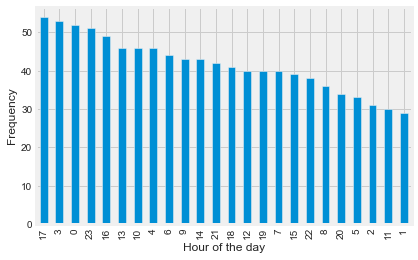

In [13]:
# Bar plot number of incidence per hour
fig, ax = plt.subplots()
#plt.figure(figsize = (18, 12))

main_df['incident_hour_of_the_day'].value_counts().plot(ax=ax, kind='bar', xlabel='Hour of the day', ylabel='Frequency')
plt.show()
# incidences mostly happens at 17.00

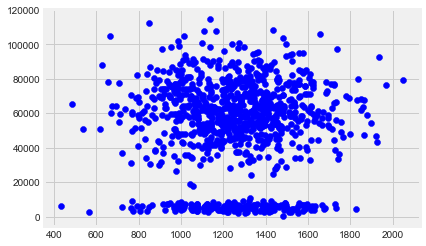

In [14]:
# scatter plot of annual premium vs total claim amount
plt.scatter(x = main_df['policy_annual_premium'], y = main_df['total_claim_amount'], c = 'blue')
plt.show()

Text(0.5, 0, 'Count')

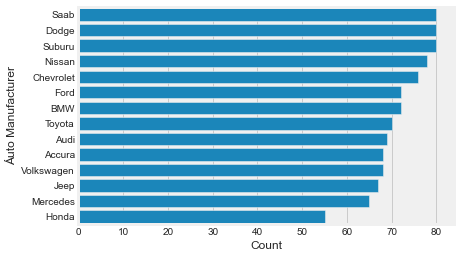

In [15]:
sns.countplot(y='auto_make',data=main_df, order = main_df['auto_make'].value_counts().index)
plt.ylabel('Áuto Manufacturer')
plt.xlabel('Count')

In [16]:
# by auto_make
fraud_by_automake = main_df.groupby(['auto_make', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_automake.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# Audi, Mercedes, ford : fraud >30%

fraud_reported
auto_make  auto_make  fraud_reported                
Accura     Accura     N                         81.0
                      Y                         19.0
Audi       Audi       N                         70.0
                      Y                         30.0
BMW        BMW        N                         72.0
                      Y                         28.0
Chevrolet  Chevrolet  N                         72.0
                      Y                         28.0
Dodge      Dodge      N                         75.0
                      Y                         25.0
Ford       Ford       N                         69.0
                      Y                         31.0
Honda      Honda      N                         75.0
                      Y                         25.0
Jeep       Jeep       N                         84.0
                      Y                         16.0
Mercedes   Mercedes   N                         66.0
                      Y                         34.0
Nissan     Nissan     N                         82.0
                      Y                         18.0
Saab       Saab       N                         78.0
                      Y                         22.0
Suburu     Suburu     N                         76.0
                      Y                         24.0
Toyota     Toyota     N                         81.0
                      Y                         19.0
Volkswagen Volkswagen N                         72.0
                      Y                         28.0

<Axes: xlabel='count', ylabel='auto_make'>

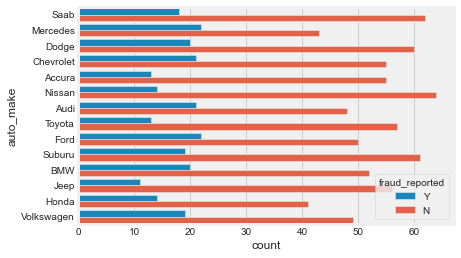

In [17]:
sns.countplot(y='auto_make',hue='fraud_reported',data=main_df)


fraud_reported
policy_csl policy_csl fraud_reported                
100/300    100/300    N                         74.0
                      Y                         26.0
250/500    250/500    N                         74.0
                      Y                         26.0
500/1000   500/1000   N                         78.0
                      Y                         22.0

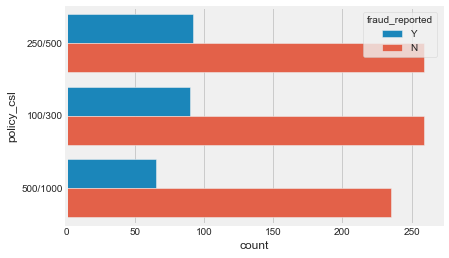

In [18]:
sns.countplot(y='policy_csl',hue='fraud_reported',data=main_df)

# policy_csl 
fraud_by_policy_csl = main_df.groupby(['policy_csl', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_policy_csl.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# csl 100/300 and 250/500 : fraud =26%

fraud_reported
insured_sex insured_sex fraud_reported                
FEMALE      FEMALE      N                         77.0
                        Y                         23.0
MALE        MALE        N                         74.0
                        Y                         26.0

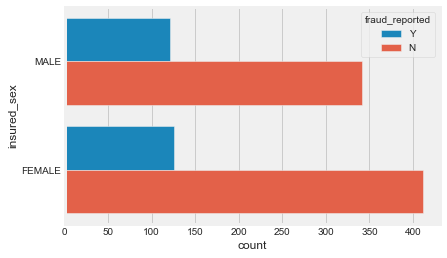

In [19]:
sns.countplot(y='insured_sex',hue='fraud_reported',data=main_df)

# insured_sex 
fraud_by_insured_sex = main_df.groupby(['insured_sex', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_insured_sex.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# male (26%) sligtly higher than female (24%) for making fraud

fraud_reported
insured_education_level insured_education_level fraud_reported                
Associate               Associate               N                         77.0
                                                Y                         23.0
College                 College                 N                         74.0
                                                Y                         26.0
High School             High School             N                         78.0
                                                Y                         22.0
JD                      JD                      N                         74.0
                                                Y                         26.0
MD                      MD                      N                         74.0
                                                Y                         26.0
Masters                 Masters                 N                         78.0
                                                Y                         22.0
PhD                     PhD                     N                         74.0
                                                Y                         26.0

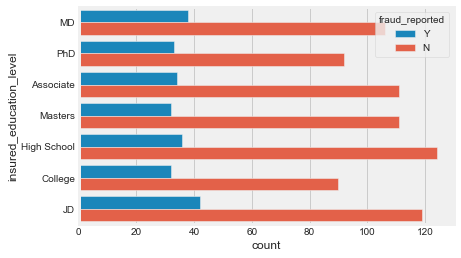

In [20]:
sns.countplot(y='insured_education_level',hue='fraud_reported',data=main_df)

# insured_education_level 
fraud_by_insured_education_level = main_df.groupby(['insured_education_level', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_insured_education_level.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# College, JD, MD, PhD fraud = 26% 

fraud_reported
incident_severity incident_severity fraud_reported                
Major Damage      Major Damage      N                         39.0
                                    Y                         61.0
Minor Damage      Minor Damage      N                         89.0
                                    Y                         11.0
Total Loss        Total Loss        N                         87.0
                                    Y                         13.0
Trivial Damage    Trivial Damage    N                         93.0
                                    Y                          7.0

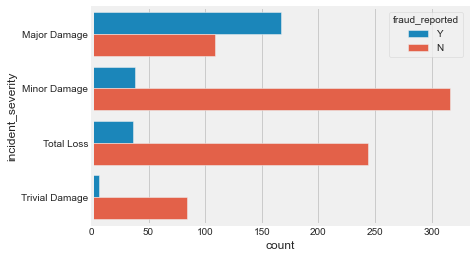

In [21]:
sns.countplot(y='incident_severity',hue='fraud_reported',data=main_df)

# incident_severity 
fraud_by_incident_severity = main_df.groupby(['incident_severity', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_incident_severity.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# Major damage 61%

fraud_reported
incident_type            incident_type            fraud_reported                
Multi-vehicle Collision  Multi-vehicle Collision  N                         73.0
                                                  Y                         27.0
Parked Car               Parked Car               N                         90.0
                                                  Y                         10.0
Single Vehicle Collision Single Vehicle Collision N                         71.0
                                                  Y                         29.0
Vehicle Theft            Vehicle Theft            N                         91.0
                                                  Y                          9.0

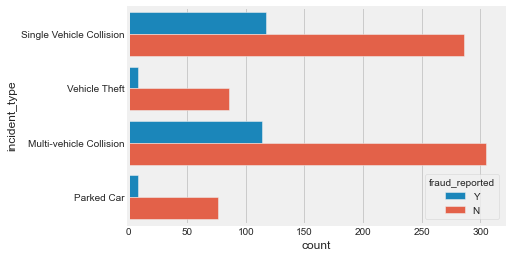

In [22]:
sns.countplot(y='incident_type',hue='fraud_reported',data=main_df)

# incident_type 
fraud_by_incident_type = main_df.groupby(['incident_type', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_incident_type.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# Single Vehicle Collision 29%

fraud_reported
insured_hobbies insured_hobbies fraud_reported                
base-jumping    base-jumping    N                         73.0
                                Y                         27.0
basketball      basketball      N                         82.0
                                Y                         18.0
board-games     board-games     N                         71.0
                                Y                         29.0
bungie-jumping  bungie-jumping  N                         84.0
                                Y                         16.0
camping         camping         N                         91.0
                                Y                          9.0
chess           chess           N                         17.0
                                Y                         83.0
cross-fit       cross-fit       N                         26.0
                                Y                         74.0
dancing         dancing         N                         88.0
                                Y                         12.0
exercise        exercise        N                         81.0
                                Y                         19.0
golf            golf            N                         89.0
                                Y                         11.0
hiking          hiking          N                         77.0
                                Y                         23.0
kayaking        kayaking        N                         91.0
                                Y                          9.0
movies          movies          N                         84.0
                                Y                         16.0
paintball       paintball       N                         77.0
                                Y                         23.0
polo            polo            N                         72.0
                                Y                         28.0
reading         reading         N                         73.0
                                Y                         27.0
skydiving       skydiving       N                         78.0
                                Y                         22.0
sleeping        sleeping        N                         80.0
                                Y                         20.0
video-games     video-games     N                         80.0
                                Y                         20.0
yachting        yachting        N                         70.0
                                Y                         30.0

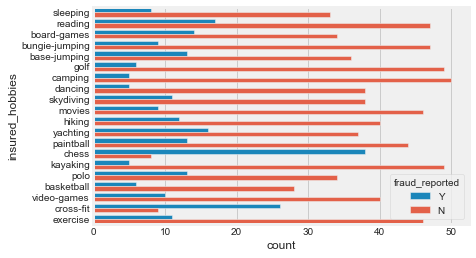

In [23]:
sns.countplot(y='insured_hobbies',hue='fraud_reported',data=main_df)

# insured_hobbies 
fraud_by_insured_hobbies = main_df.groupby(['insured_hobbies', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_insured_hobbies.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# Chess 83%, cross-fit 71%

fraud_reported
insured_occupation insured_occupation fraud_reported                
adm-clerical       adm-clerical       N                         83.0
                                      Y                         17.0
armed-forces       armed-forces       N                         75.0
                                      Y                         25.0
craft-repair       craft-repair       N                         70.0
                                      Y                         30.0
exec-managerial    exec-managerial    N                         63.0
                                      Y                         37.0
farming-fishing    farming-fishing    N                         70.0
                                      Y                         30.0
handlers-cleaners  handlers-cleaners  N                         80.0
                                      Y                         20.0
machine-op-inspct  machine-op-inspct  N                         76.0
                                      Y                         24.0
other-service      other-service      N                         83.0
                                      Y                         17.0
priv-house-serv    priv-house-serv    N                         83.0
                                      Y                         17.0
prof-specialty     prof-specialty     N                         79.0
                                      Y                         21.0
protective-serv    protective-serv    N                         78.0
                                      Y                         22.0
sales              sales              N                         72.0
                                      Y                         28.0
tech-support       tech-support       N                         72.0
                                      Y                         28.0
transport-moving   transport-moving   N                         71.0
                                      Y                         29.0

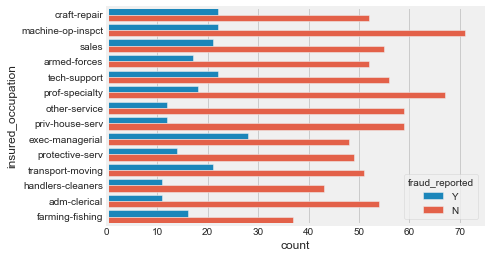

In [24]:
sns.countplot(y='insured_occupation',hue='fraud_reported',data=main_df)

# insured_hobbies 
fraud_by_insured_occupation = main_df.groupby(['insured_occupation', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_insured_occupation.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# exec-managerial 37%

In [25]:
main_df.fraud_reported.value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

In [26]:
# Modify target variable from Y/N to 1/0
main_df.fraud_reported = (main_df.fraud_reported == 'Y').astype('int64')

In [27]:
main_df.fraud_reported.value_counts()

fraud_reported
0    753
1    247
Name: count, dtype: int64

In [28]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

In [29]:
# extracting the numerical columns

num_df = main_df.select_dtypes(include = ['int64', 'float64'])

# extracting categorical columns

cat_df = main_df.select_dtypes(include = ['object'])

for col in cat_df.columns:
    print(f"{col}: \n{cat_df[col].unique()}\n")
    
to_drop_cat = ['incident_location','incident_state','incident_city']
# remove 'incident_location','incident_state','incident_city'
cat_df.drop(to_drop_cat, inplace = True, axis = 1)


policy_state: 
['OH' 'IN' 'IL']

policy_csl: 
['250/500' '100/300' '500/1000']

insured_sex: 
['MALE' 'FEMALE']

insured_education_level: 
['MD' 'PhD' 'Associate' 'Masters' 'High School' 'College' 'JD']

insured_occupation: 
['craft-repair' 'machine-op-inspct' 'sales' 'armed-forces' 'tech-support'
 'prof-specialty' 'other-service' 'priv-house-serv' 'exec-managerial'
 'protective-serv' 'transport-moving' 'handlers-cleaners' 'adm-clerical'
 'farming-fishing']

insured_hobbies: 
['sleeping' 'reading' 'board-games' 'bungie-jumping' 'base-jumping' 'golf'
 'camping' 'dancing' 'skydiving' 'movies' 'hiking' 'yachting' 'paintball'
 'chess' 'kayaking' 'polo' 'basketball' 'video-games' 'cross-fit'
 'exercise']

insured_relationship: 
['husband' 'other-relative' 'own-child' 'unmarried' 'wife' 'not-in-family']

incident_type: 
['Single Vehicle Collision' 'Vehicle Theft' 'Multi-vehicle Collision'
 'Parked Car']

collision_type: 
['Side Collision' 'Rear Collision' 'Front Collision']

incident_severit

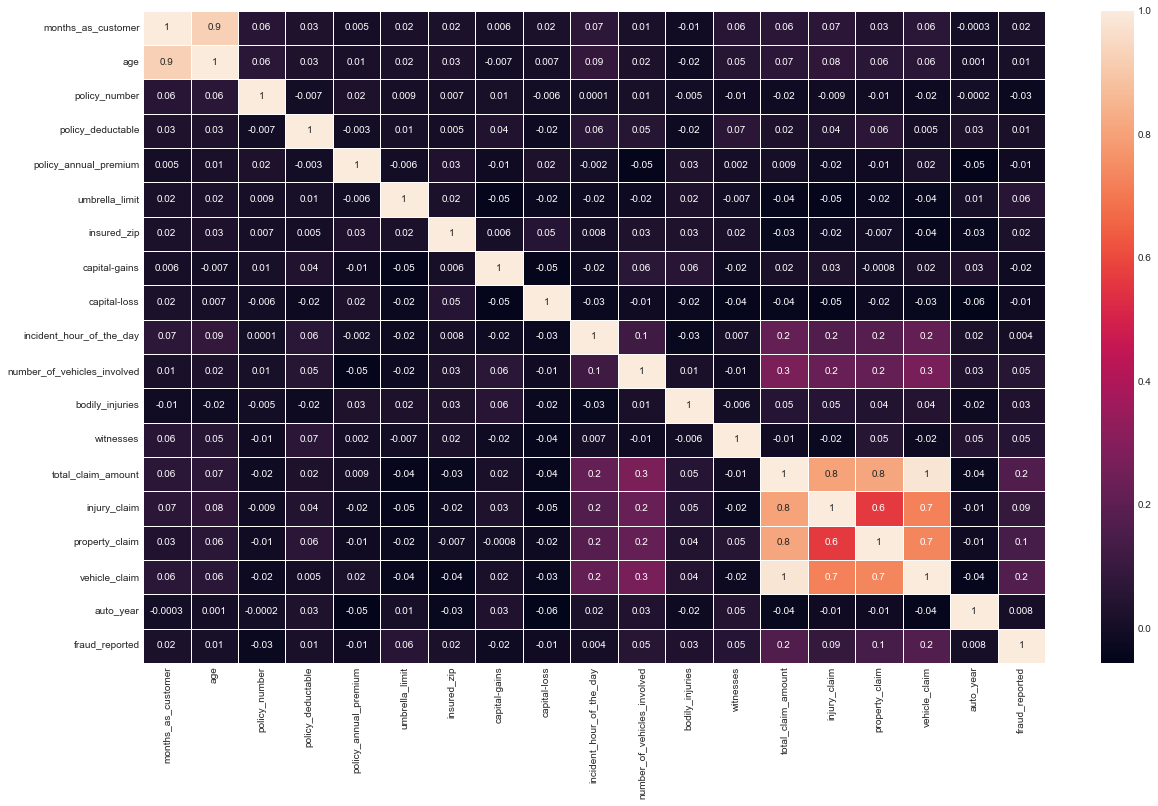

In [30]:
# Heatmap correlation plot for all variables

plt.figure(figsize = (18, 12))

corr = num_df.corr()
#mask = np.triu(np.ones_like(corr, dtype = bool))
# mask = mask,
sns.heatmap(data = corr,  annot = True, fmt = '.1g', linewidth = 1)
plt.show()

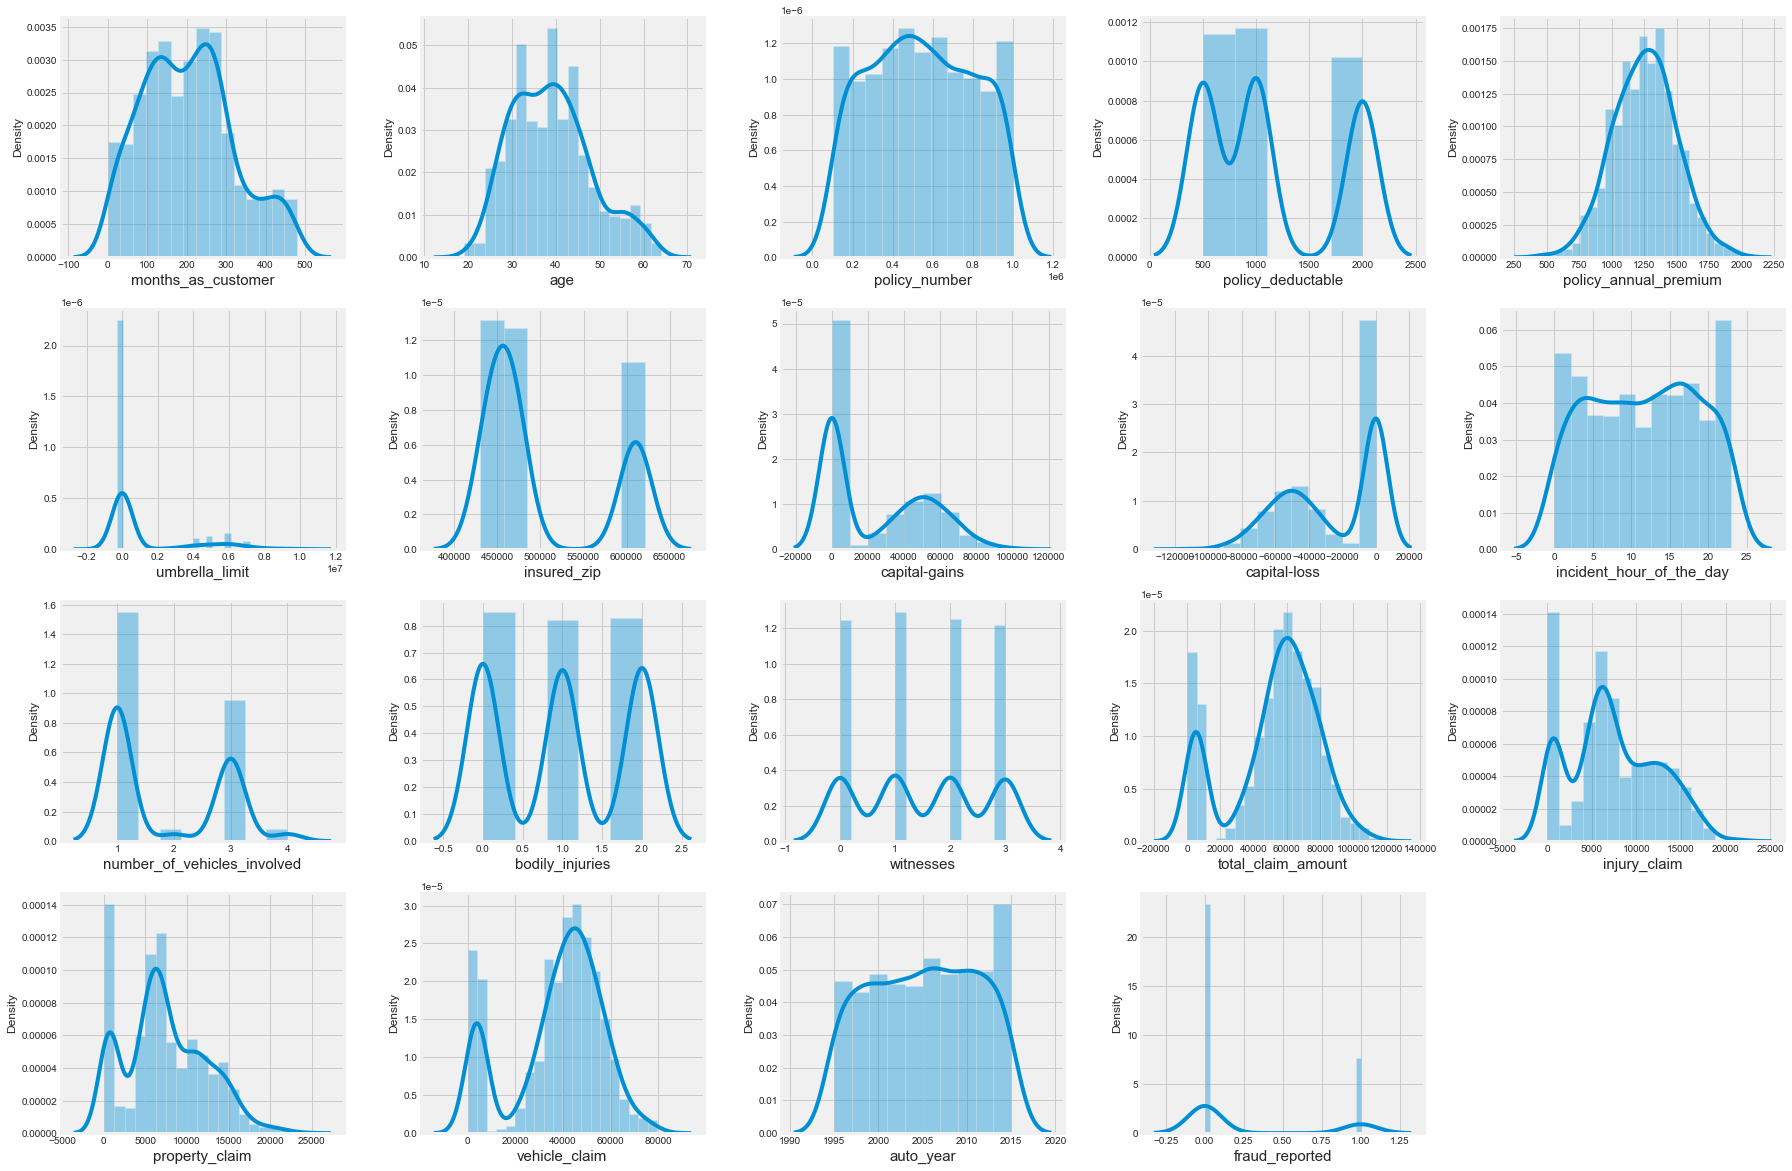

In [31]:
# Histogram of Continuous variable
plt.figure(figsize = (25, 20))
plotnumber = 1

for col in num_df.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.distplot(num_df[col])
        plt.xlabel(col, fontsize = 15)
        
    plotnumber += 1
    
plt.tight_layout()
plt.show()

In [32]:
# separating the feature and target columns

# outcome
y = num_df['fraud_reported']

# features
num_df.drop('fraud_reported', inplace = True ,axis = 1)

In [33]:
# categorical variable to dummies

cat_df = pd.get_dummies(cat_df, drop_first = True)

In [34]:
# combining the Numerical and Categorical dataframes to get the final dataset

X = pd.concat([num_df, cat_df], axis = 1)

# Modeling

In [35]:
# # Data splitting
 
# df_full_train, df_test = train_test_split(main_df, test_size=0.2, random_state=1)


In [36]:
# main_df.select_dtypes(include = ['object']).columns

In [37]:
# numerical = ['months_as_customer', 'age', 'policy_number', 'policy_deductable',
#        'policy_annual_premium', 'umbrella_limit', 'insured_zip',
#        'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
#        'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
#        'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim',
#        'auto_year']
 
# categorical = ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level',
#        'insured_occupation', 'insured_hobbies', 'insured_relationship',
#        'incident_type', 'collision_type', 'incident_severity',
#        'authorities_contacted', 'incident_state', 'incident_city',
#        'incident_location', 'property_damage', 'police_report_available',
#        'auto_make', 'auto_model']

In [38]:
# def train(df_train, y_train, C=1.0):
#     dicts = df_train[categorical + numerical].to_dict(orient='records')
 
#     dv = DictVectorizer(sparse=False)
#     X_train = dv.fit_transform(dicts)
 
#     model_logreg = LogisticRegression(C=C, max_iter=1000)
#     model_logreg.fit(X_train, y_train)
 
#     return dv, model

In [39]:
# def predict(df, dv, model):
#      dicts = df[categorical + numerical].to_dict(orient='records')
 
#      X = dv.transform(dicts)
#      y_pred = model.predict_proba(X)[:,1]
 
#      return y_pred

In [40]:
# C = 1.0
# n_splits = 10

In [41]:
# kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)  
 
# scores = []
 
# for train_idx, val_idx in kfold.split(df_full_train):
#     df_train = df_full_train.iloc[train_idx]
#     df_val = df_full_train.iloc[val_idx]
 
#     y_train = df_train.fraud_reported.values
#     y_val = df_val.fraud_reported.values
 
#     dv, model = train(df_train, y_train, C=C)
#     y_pred = predict(df_val, dv, model)
 
#     auc = roc_auc_score(y_val, y_pred)
#     scores.append(auc)
 
# print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

In [42]:
# dv, model = train(df_full_train, df_full_train.fraud_reported.values, C=1.0)
# y_pred = predict(df_test, dv, model)
# y_test = df_test.fraud_reported.values
 
# auc = roc_auc_score(y_test, y_pred)
# auc

In [43]:
# splitting data into training set and test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [44]:
classifiers = [
    ['CatBoostClassifier',CatBoostClassifier(silent=True)],
    ['LogisticRegression',LogisticRegression(class_weight='balanced',random_state=1)],
    ['DecisionTree',DecisionTreeClassifier(class_weight='balanced',random_state=1)],
    ['LightGBM',LGBMClassifier(class_weight='balanced',metric='binary_logloss')],
    ['SVC', SVC()],
    ['KNN', KNeighborsClassifier(n_neighbors = 30)],
    ['GradientBoosting', GradientBoostingClassifier()],
    ['RandomForest', RandomForestClassifier()],
    ['XGBoost', XGBClassifier()]]

In [45]:
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score
)

def modelling(classifiers, X_train, y_train, X_test, y_test):
    """
    Train multiple classifiers and collect predictions, probabilities, and runtime
    """
    
    model_results = []

    for name, model in classifiers:
        start_time = time.time()
        
        # Train model
        model.fit(X_train, y_train)
        
        runtime = time.time() - start_time
        
        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Probabilities (handle models without predict_proba)
        if hasattr(model, "predict_proba"):
            y_train_proba = model.predict_proba(X_train)[:, 1]
            y_test_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_train_proba = model.decision_function(X_train)
            y_test_proba = model.decision_function(X_test)
        else:
            y_train_proba = None
            y_test_proba = None
        
        model_results.append({
            "model_name": name,
            "runtime": runtime,
            "y_train": y_train,
            "y_test": y_test,
            "y_train_pred": y_train_pred,
            "y_test_pred": y_test_pred,
            "y_train_proba": y_train_proba,
            "y_test_proba": y_test_proba
        })
        
    return model_results


In [46]:
def process_eval(model_results, overfit_threshold=10):
    """
    Evaluate models and return comparison table
    """
    
    rows = []

    for res in model_results:
        y_train = res["y_train"]
        y_test = res["y_test"]
        
        y_train_pred = res["y_train_pred"]
        y_test_pred = res["y_test_pred"]
        
        # Metrics
        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        
        train_recall = recall_score(y_train, y_train_pred)
        test_recall = recall_score(y_test, y_test_pred)
        
        train_precision = precision_score(y_train, y_train_pred)
        test_precision = precision_score(y_test, y_test_pred)
        
        train_f1 = f1_score(y_train, y_train_pred)
        test_f1 = f1_score(y_test, y_test_pred)
        
        # AUC (safe handling)
        if res["y_train_proba"] is not None:
            train_auc = roc_auc_score(y_train, res["y_train_proba"])
            test_auc = roc_auc_score(y_test, res["y_test_proba"])
        else:
            train_auc = np.nan
            test_auc = np.nan
        
        # Overfitting detection
        diff = train_accuracy - test_accuracy
        diff_percentage = diff * 100
        is_overfitting = diff_percentage > overfit_threshold
        
        rows.append({
            "model_name": res["model_name"],
            "runtime": round(res["runtime"], 3),
            "train_accuracy": round(train_accuracy, 4),
            "test_accuracy": round(test_accuracy, 4),
            "train_recall": round(train_recall, 4),
            "test_recall": round(test_recall, 4),
            "train_precision": round(train_precision, 4),
            "test_precision": round(test_precision, 4),
            "train_f1_score": round(train_f1, 4),
            "test_f1_score": round(test_f1, 4),
            "train_auc": round(train_auc, 4),
            "test_auc": round(test_auc, 4),
            "diff_percentage": round(diff_percentage, 2),
            "diff": round(diff, 4),
            "is_overfitting": is_overfitting
        })

    df = pd.DataFrame(rows)
    
    # Define best model (highest test F1, fallback to AUC)
    best_idx = (
        df["test_f1_score"]
        .fillna(0)
        .idxmax()
    )
    
    df["is_best_model"] = False
    df.loc[best_idx, "is_best_model"] = True
    
    return df


In [47]:
model_result=modelling(classifiers,X_train,y_train,X_test,y_test)
result=process_eval(model_result)

result

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 199, number of negative: 601
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2614
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,model_name,runtime,train_accuracy,test_accuracy,train_recall,test_recall,train_precision,test_precision,train_f1_score,test_f1_score,train_auc,test_auc,diff_percentage,diff,is_overfitting,is_best_model
0,CatBoostClassifier,4.225,0.9838,0.830,0.9347,0.5208,1.0000,0.6944,0.9662,0.5952,0.9991,0.8712,15.38,0.1538,True,False
1,LogisticRegression,0.067,0.5687,0.565,0.6281,0.5208,0.3157,0.2809,0.4202,0.3650,0.6228,0.5791,0.38,0.0038,False,False
2,DecisionTree,0.017,1.0000,0.755,1.0000,0.5000,1.0000,0.4898,1.0000,0.4948,1.0000,0.6678,24.50,0.2450,True,False
3,LightGBM,2.089,1.0000,0.820,1.0000,0.5625,1.0000,0.6429,1.0000,0.6000,1.0000,0.8554,18.00,0.1800,True,True
4,SVC,0.058,0.7512,0.760,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5592,0.5704,-0.88,-0.0088,False,False
5,KNN,0.000,0.7512,0.760,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6249,0.5149,-0.88,-0.0088,False,False
6,GradientBoosting,0.514,0.9700,0.820,0.9045,0.5208,0.9730,0.6579,0.9375,0.5814,0.9929,0.8679,15.00,0.1500,True,False
7,RandomForest,0.278,1.0000,0.755,1.0000,0.0833,1.0000,0.4444,1.0000,0.1404,1.0000,0.8506,24.50,0.2450,True,False
8,XGBoost,0.298,1.0000,0.810,1.0000,0.4375,1.0000,0.6562,1.0000,0.5250,1.0000,0.8459,19.00,0.1900,True,False


In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

def get_param_grid(model_name):
    grids = {
        "LogisticRegression": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear"]
        },
        "RandomForest": {
            "model__n_estimators": [100, 300],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5]
        },
        "XGBoost": {
            "model__n_estimators": [100, 300],
            "model__max_depth": [3, 6],
            "model__learning_rate": [0.01, 0.1]
        },
        "LightGBM": {
            "model__n_estimators": [100, 300],
            "model__num_leaves": [31, 63],
            "model__learning_rate": [0.01, 0.1]
        }
    }
    return grids.get(model_name, {})


In [49]:
def tune_best_model(
    best_model_name,
    classifiers,
    X_train,
    y_train,
    scoring="f1"
):
    # Get model
    model = dict(classifiers)[best_model_name]
    
    pipe = Pipeline([
        ("model", model)
    ])
    
    param_grid = get_param_grid(best_model_name)
    
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=10,
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X_train, y_train)
    
    return grid.best_estimator_, grid.best_params_, grid.best_score_


In [50]:
best_model_name = result.loc[result["is_best_model"], "model_name"].values[0]

best_estimator, best_params, best_cv_score = tune_best_model(
    best_model_name,
    classifiers,
    X_train,
    y_train
)

print("Best Model:", best_model_name)
print("Best Params:", best_params)
print("Best CV F1 Score:", best_cv_score)


Fitting 10 folds for each of 8 candidates, totalling 80 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 199, number of negative: 601
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000781 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2614
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best Model: LightGBM
Best Params: {'model__learning_rate': 0.01, 'model__n_estimators': 100, 'model__num_leaves': 31}
Best CV F1 Score: 0.704265663339757


In [52]:
import shap
import matplotlib.pyplot as plt


In [59]:
def shap_feature_importance_tree(model, X_train, top_n=10):
    import shap
    
    explainer = shap.TreeExplainer(model["model"])
    shap_values = explainer.shap_values(X_train)

    # 🔴 FIX: Binary classification returns list
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap.summary_plot(
        shap_values,
        X_train,
        max_display=top_n,
        show=True
    )

def shap_feature_importance(model, X_train, top_n=10):
    import shap

    explainer = shap.Explainer(model["model"], X_train)
    shap_values = explainer(X_train)

    # 🔴 FIX: Extract matrix explicitly
    shap_values = shap_values.values

    shap.summary_plot(
        shap_values,
        X_train,
        max_display=top_n,
        show=True
    )


In [61]:
feature_names = X_train.columns.tolist()

shap_feature_importance_tree(
    best_estimator,
    X_train,
    feature_names
)

TypeError: '<' not supported between instances of 'int' and 'list'

In [ ]:
# Support Vector Classifier (SVC)


svc = SVC()
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

# accuracy_score

svc_train_acc = accuracy_score(y_train, svc.predict(X_train))
svc_test_acc = accuracy_score(y_test, y_pred)
svc_test_auc = roc_auc_score(y_test, y_pred)

print(f"Training accuracy of Support Vector Classifier is : {svc_train_acc}")
print(f"Test accuracy of Support Vector Classifier is : {svc_test_acc}")
print(f"AUC of Support Vector Classifier is : {svc_test_auc}")

Training accuracy of Support Vector Classifier is : 0.7575
Test accuracy of Support Vector Classifier is : 0.735
AUC of Support Vector Classifier is : 0.5


In [ ]:
# KNN



knn = KNeighborsClassifier(n_neighbors = 30)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# accuracy_score

knn_train_acc = accuracy_score(y_train, knn.predict(X_train))
knn_test_acc = accuracy_score(y_test, y_pred)
knn_test_auc = roc_auc_score(y_test, y_pred)

print(f"Training accuracy of KNN is : {knn_train_acc}")
print(f"Test accuracy of KNN is : {knn_test_acc}")
print(f"AUC of KNN is : {knn_test_auc}")

Training accuracy of KNN is : 0.7575
Test accuracy of KNN is : 0.735
AUC of KNN is : 0.5


In [ ]:
# Decision tree classifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

dtc_train_acc = accuracy_score(y_train, dtc.predict(X_train))
dtc_test_acc = accuracy_score(y_test, y_pred)
dtc_test_auc = roc_auc_score(y_test, y_pred)

print(f"Training accuracy of Decision Tree is : {dtc_train_acc}")
print(f"Test accuracy of Decision Tree is : {dtc_test_acc}")
print(f"AUC of Decision Tree is : {dtc_test_auc}")

# hyper parameter tuning

from sklearn.model_selection import GridSearchCV

grid_params = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [3, 5, 7, 10],
    'min_samples_split' : range(2, 10, 1),
    'min_samples_leaf' : range(2, 10, 1)
}

grid_search = GridSearchCV(dtc, grid_params, cv = 10, n_jobs = -1, verbose = 1)
grid_search.fit(X_train, y_train)

# best parameters and best score

print(grid_search.best_params_)
print(grid_search.best_score_)

# best estimator 

dtc = grid_search.best_estimator_

y_pred = dtc.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dtc_train_acc = accuracy_score(y_train, dtc.predict(X_train))
dtc_test_acc = accuracy_score(y_test, y_pred)
dtc_test_auc = roc_auc_score(y_test, y_pred)

print(f"Training accuracy of Decision Tree is : {dtc_train_acc}")
print(f"Test accuracy of Decision Tree is : {dtc_test_acc}")
print(f"AUC of Decision Tree is : {dtc_test_auc}")

Training accuracy of Decision Tree is : 1.0
Test accuracy of Decision Tree is : 0.765
AUC of Decision Tree is : 0.7134514183031704
Fitting 10 folds for each of 512 candidates, totalling 5120 fits
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 2}
0.8550000000000001
Training accuracy of Decision Tree is : 0.865
Test accuracy of Decision Tree is : 0.82
AUC of Decision Tree is : 0.7568989860094982


In [ ]:
# Random forest classifier


rand_clf = RandomForestClassifier(criterion= 'entropy', max_depth= 10, max_features= 'sqrt', min_samples_leaf= 1, min_samples_split= 3, n_estimators= 140)
rand_clf.fit(X_train, y_train)

y_pred = rand_clf.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rand_clf_train_acc = accuracy_score(y_train, rand_clf.predict(X_train))
rand_clf_test_acc = accuracy_score(y_test, y_pred)
rand_clf_test_auc = roc_auc_score(y_test, y_pred)

print(f"Training accuracy of Random Forest is : {rand_clf_train_acc}")
print(f"Test accuracy of Random Forest is : {rand_clf_test_acc}")
print(f"AUC of Random Forest is : {rand_clf_test_auc}")

Training accuracy of Random Forest is : 0.945
Test accuracy of Random Forest is : 0.715
AUC of Random Forest is : 0.49845976126299574


In [ ]:
# Gradient Boosting



gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of gradient boosting classifier

gb_acc = accuracy_score(y_test, gb.predict(X_test))
gb_auc = roc_auc_score(y_test, gb.predict(X_test))

print(f"Training Accuracy of Gradient Boosting Classifier is {accuracy_score(y_train, gb.predict(X_train))}")
print(f"Test Accuracy of Gradient Boosting Classifier is {gb_acc} \n")
print(f"Test AUC of Gradient Boosting Classifier is {gb_auc} \n")

Training Accuracy of Gradient Boosting Classifier is 0.9675
Test Accuracy of Gradient Boosting Classifier is 0.795 

Test AUC of Gradient Boosting Classifier is 0.7398921832884098 



In [59]:
# Stocastic Gradient boosting

sgb = GradientBoostingClassifier(subsample = 0.90, max_features = 0.70)
sgb.fit(X_train, y_train)

# accuracy score, confusion matrix and classification report of stochastic gradient boosting classifier

sgb_acc = accuracy_score(y_test, sgb.predict(X_test))
sgb_auc = roc_auc_score(y_test, sgb.predict(X_test))

print(f"Training Accuracy of Stochastic Gradient Boosting is {accuracy_score(y_train, sgb.predict(X_train))}")
print(f"Test Accuracy of Stochastic Gradient Boosting is {sgb_acc} \n")
print(f"AUC of Stochastic Gradient Boosting is {sgb_auc} \n")

Training Accuracy of Stochastic Gradient Boosting is 0.97
Test Accuracy of Stochastic Gradient Boosting is 0.795 

AUC of Stochastic Gradient Boosting is 0.7278269798485433 



In [62]:
# Model Comparison

models = pd.DataFrame({
    'Model' : ['SVC', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boost', 'SGB' ], # ,'XgBoost' , ,'Ada Boost'
    'AUC' : [svc_test_auc, knn_test_auc, dtc_test_auc, rand_clf_test_auc, gb_auc, sgb_auc] #, xgb_test_acc, ada_test_acc,
})


models.sort_values(by = 'AUC', ascending = False)

,Model,AUC
2,Decision Tree,0.756899
4,Gradient Boost,0.739892
5,SGB,0.727827
0,SVC,0.500000
1,KNN,0.500000
3,Random Forest,0.498460


In [63]:
grid_search

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': range(2, 10),
                         'min_samples_split': range(2, 10)},
             verbose=1)

In [64]:
dtc

DecisionTreeClassifier(max_depth=5, min_samples_leaf=6)